## Hierarchical Hawkes functions: a toy example
This notebook demonstrates a toy example of an hierarchical Hawkes function (HHF). The functions used in this notebook to obtain the HHF intensity are in the package `hierarchical_hawkes`. Instructions for installation can be found in the main `README` file for this repository.  

In [67]:
import hierarchical_hawkes as hhf

For plotting, we use `matplotlib` with LaTeX rendering via `tikz` for high-quality figures. Lines 3 and 4 in the following code block configure LaTeX rendering with Times font. These lines can be removed if standard matplotlib rendering is preferred; in that case, only `import matplotlib.pyplot as plt` is required.

In [68]:
import matplotlib.pyplot as plt
## Compile with tikz and times font
plt.rc('text', usetex=True)
plt.rc('font', family='times')

First, we specify the parameters of the process we would like to simulate. We set a time horizon $T=50$, with pre-specified changepoints at $\tau_1=5$, $\tau_2=15$, $\tau_3=20$ and $\tau_4=40$. The process parameters are $\lambda_0=0.1$, $\theta_{0,\alpha}=0.25$, $\eta_{\alpha}=0.2$, $\xi_{\alpha}=0.1$, $\theta_{0,\beta}=0.5$, $\eta_{\beta}=0.4$, $\xi_{\beta}=0.05$.  

In [69]:
import numpy as np
jumps = np.array([5, 15, 20, 40])
lambda0 = 0.1
theta0_alpha = 0.25
theta0_beta = 0.5
theta0_delta = 1.5
eta_alpha = 0.2
eta_beta = 0.3
eta_delta = 1.0
csi_alpha = 0.1
csi_beta = 0.05
csi_delta = 0.15

Next, we calculate the values of $\alpha(\tau_j)$ and $\beta(\tau_j)$ for all changepoints:

In [70]:
## Calculate the values of alpha and beta at the jumps
alphas = hhf.inhibitory_hawkes_intensity(jumps, jumps, theta0_alpha, eta_alpha, csi_alpha)
betas = hhf.inhibitory_hawkes_intensity(jumps, jumps, theta0_beta, eta_beta, csi_beta)
deltas = hhf.inhibitory_hawkes_intensity(jumps, jumps, theta0_delta, eta_delta, csi_delta)

Using these values, we can calculate $\lambda(t)$ in $t\in[0,T]$ as follows: 

In [71]:
## Generate the time grid
T = 50
time_grid = np.linspace(0, T, 1000)
ints = np.ones_like(time_grid) * lambda0
# Calculate the intensity function
for j, jump in enumerate(jumps):
    c1 = alphas[j] / deltas[j] * np.clip(time_grid - jump, 0, deltas[j]) * (1 - np.heaviside(time_grid - jump - deltas[j], 1))
    c2 = np.heaviside(time_grid - jump - deltas[j], 1) * alphas[j] * np.exp(-betas[j] * (time_grid - jump - deltas[j]))  
    ints += (c1 + c2) * np.heaviside(time_grid - jump, 1)

Text(6.875, 0.115, '$\\alpha(\\tau_1)$')

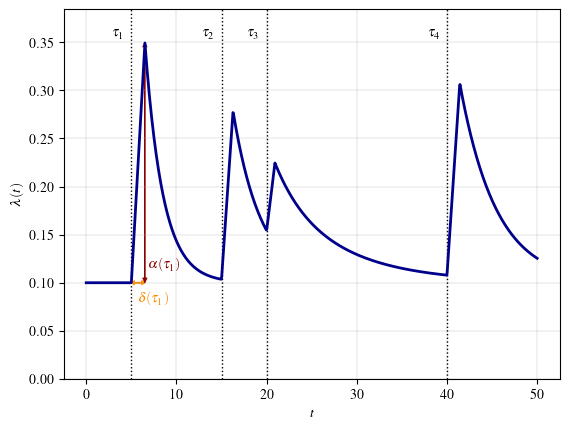

In [136]:
## Plot the intensity function
for jump in jumps:
    plt.axvline(x=jump, color='black', linestyle='dotted', linewidth=1)
plt.plot(time_grid, ints, color='darkblue', linewidth=2, label='Fitted cluster intensity')
plt.ylim(0, np.max(ints) + np.max(ints) / 10)
plt.xlabel(r'$t$')
plt.ylabel(r'$\lambda(t)$')
plt.grid(linewidth=0.25)
## Add text next to changepoints
for j, jump in enumerate(jumps):
    plt.text(jump - 1.5, np.max(ints) * 1.02, r'$\tau_{'+str(j+1)+'}$', fontsize=10, color='black', ha='center')
##plt.savefig('../figures/example1_lambda.pdf', bbox_inches='tight')
plt.arrow(jumps[0], 0.1, deltas[0], 0, head_width=0.005, head_length=0.35, fc='darkorange', ec='darkorange', length_includes_head=True, linewidth=0.5)
plt.arrow(jumps[0] + deltas[0], 0.1, -deltas[0], 0, head_width=0.005, head_length=0.35, fc='darkorange', ec='darkorange', length_includes_head=True, linewidth=0.5)
plt.text(jumps[0] + 0.5 * deltas[0], 0.08, r'$\delta(\tau_1)$', fontsize=10, color='darkorange', ha='left')
plt.arrow(jumps[0] + deltas[0], 0.1, 0, alphas[0], head_width=0.5, head_length=0.005, fc='darkred', ec='darkred', length_includes_head=True, linewidth=0.5)
plt.arrow(jumps[0] + deltas[0], alphas[0] + lambda0, 0, -alphas[0], head_width=0.5, head_length=0.005, fc='darkred', ec='darkred', length_includes_head=True, linewidth=0.5)
plt.text(jumps[0] + 0.5 * 2.5 * deltas[0], 0.115, r'$\alpha(\tau_1)$', fontsize=10, color='darkred', ha='left')


Additionally, the intensities of $\alpha(t)$ and $\beta(t)$ for $t\in[0,T]$ can also be visualised: 

In [73]:
## Intensities for alpha and beta
ints_alpha = hhf.inhibitory_hawkes_intensity(time_grid, jumps, theta0_alpha, eta_alpha, csi_alpha)
ints_beta = hhf.inhibitory_hawkes_intensity(time_grid, jumps, theta0_beta, eta_beta, csi_beta)
ints_delta = hhf.inhibitory_hawkes_intensity(time_grid, jumps, theta0_delta, eta_delta, csi_delta)

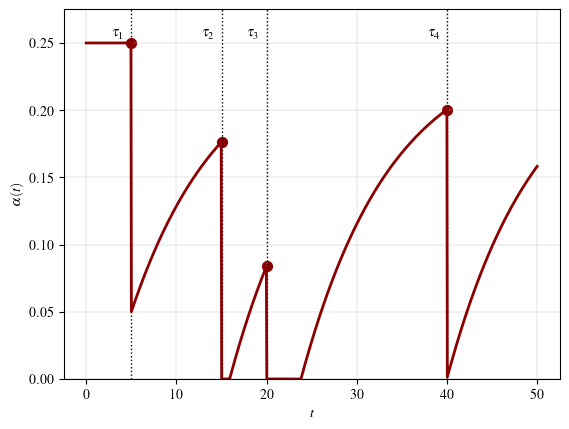

In [78]:
## Plot the intensity function
for jump in jumps:
    plt.axvline(x=jump, color='black', linestyle='dotted', linewidth=1)
plt.plot(time_grid, ints_alpha, color='darkred', linewidth=2, label='Fitted cluster intensity')
plt.scatter(jumps, alphas, color='darkred', s=50, label='Intensity at jumps')
plt.ylim(0, np.max(ints_alpha) + np.max(ints_alpha) / 10)
plt.xlabel(r'$t$')
plt.ylabel(r'$\alpha(t)$')
plt.grid(linewidth=0.25)
## Add text next to changepoints
for j, jump in enumerate(jumps):
    plt.text(jump - 1.5, np.max(ints_alpha) * 1.02, r'$\tau_{'+str(j+1)+'}$', fontsize=10, color='black', ha='center')
plt.savefig('../figures/example1_alpha.pdf', bbox_inches='tight')
plt.show()

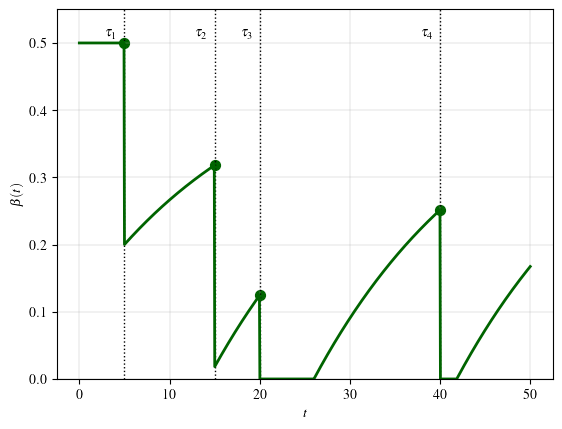

In [79]:
for jump in jumps:
    plt.axvline(x=jump, color='black', linestyle='dotted', linewidth=1)
plt.plot(time_grid, ints_beta, color='darkgreen', linewidth=2, label='Fitted cluster intensity')
plt.scatter(jumps, betas, color='darkgreen', s=50, label='Intensity at jumps')
plt.ylim(0, np.max(ints_beta) + np.max(ints_beta) / 10)
plt.xlabel(r'$t$')
plt.ylabel(r'$\beta(t)$')
plt.grid(linewidth=0.25)
## Add text next to changepoints
for j, jump in enumerate(jumps):
    plt.text(jump - 1.5, np.max(ints_beta) * 1.02, r'$\tau_{'+str(j+1)+'}$', fontsize=10, color='black', ha='center')
plt.savefig('../figures/example1_beta.pdf', bbox_inches='tight')
plt.show()

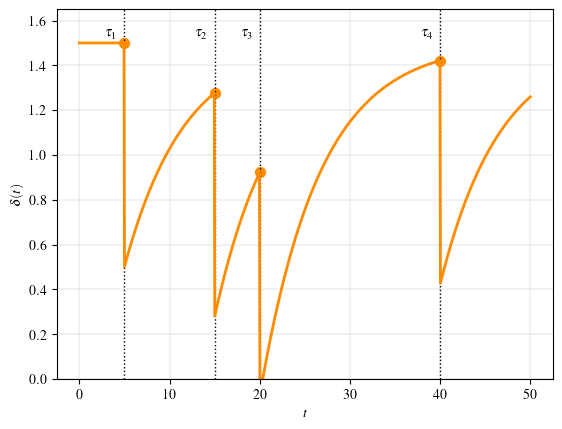

In [80]:
for jump in jumps:
    plt.axvline(x=jump, color='black', linestyle='dotted', linewidth=1)
plt.plot(time_grid, ints_delta, color='darkorange', linewidth=2, label='Fitted cluster intensity')
plt.scatter(jumps, deltas, color='darkorange', s=50, label='Intensity at jumps')
plt.ylim(0, np.max(ints_delta) + np.max(ints_delta) / 10)
plt.xlabel(r'$t$')
plt.ylabel(r'$\delta(t)$')
plt.grid(linewidth=0.25)
## Add text next to changepoints
for j, jump in enumerate(jumps):
    plt.text(jump - 1.5, np.max(ints_delta) * 1.02, r'$\tau_{'+str(j+1)+'}$', fontsize=10, color='black', ha='center')
plt.savefig('../figures/example1_delta.pdf', bbox_inches='tight')
plt.show()